In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

import yfinance as yf

In [30]:
df = yf.download(
    "AAPL",
    start="2015-01-01",
    end="2025-01-01",
    auto_adjust=True
)

[*********************100%***********************]  1 of 1 completed


In [32]:
df.reset_index(inplace=True)

In [33]:
df.head()

Price,index,Date,Close,High,Low,Open,Volume
Ticker,,,AAPL,AAPL,AAPL,AAPL,AAPL
0,0,2015-01-02,24.192598,24.659500,23.754462,24.648436,212818400
1,1,2015-01-05,23.511063,24.042136,23.325188,23.962475,257142000
2,2,2015-01-06,23.513277,23.772175,23.152589,23.575235,263188400
3,3,2015-01-07,23.842987,23.942563,23.610642,23.721282,160423600
4,4,2015-01-08,24.759077,24.816610,24.053192,24.170472,237458000


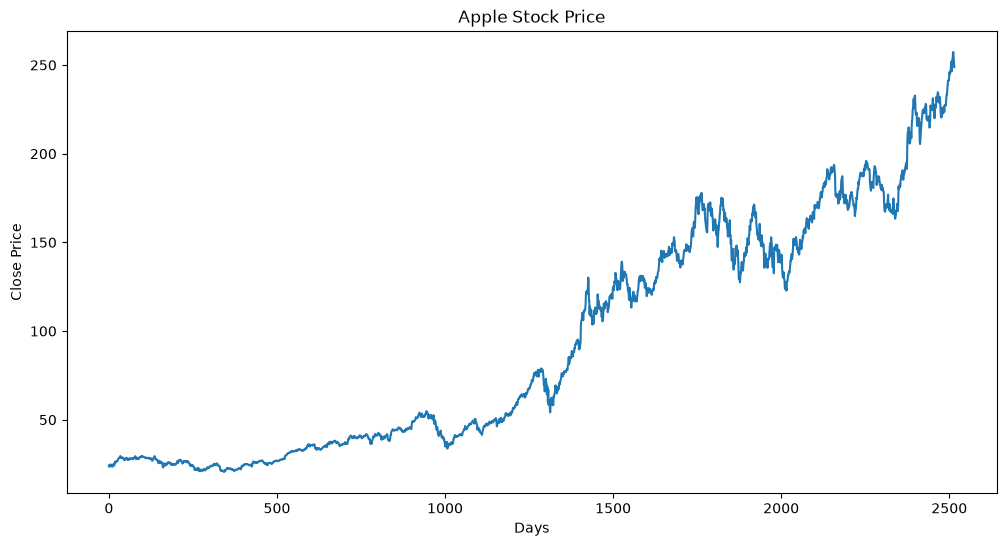

In [34]:
plt.figure(figsize=(12,6))
plt.plot(df["Close"])
plt.xlabel("Days")
plt.ylabel("Close Price")
plt.title("Apple Stock Price")
plt.show()

In [36]:
data = df["Close"].values
data = data.reshape(-1,1)

In [37]:
scaler = MinMaxScaler(feature_range=(0,1))

scaled_data = scaler.fit_transform(data)

In [38]:
training_size = int(len(scaled_data)*0.8)

train_data = scaled_data[:training_size]
test_data = scaled_data[training_size:]

In [39]:
def create_dataset(dataset, time_step=60):

    X = []
    y = []

    for i in range(time_step, len(dataset)):
        X.append(dataset[i-time_step:i,0])
        y.append(dataset[i,0])

    return np.array(X), np.array(y)

In [40]:
X_train, y_train = create_dataset(train_data)

X_test, y_test = create_dataset(test_data)

In [41]:
X_train = X_train.reshape(
    X_train.shape[0],
    X_train.shape[1],
    1
)

X_test = X_test.reshape(
    X_test.shape[0],
    X_test.shape[1],
    1
)

In [42]:
model = Sequential()

model.add(
    LSTM(
        50,
        return_sequences=True,
        input_shape=(60,1)
    )
)

model.add(
    LSTM(50)
)

model.add(
    Dense(1)
)

/Users/rimzimkulhara/Desktop/Stock-Price-Prediction/venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [43]:
model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

In [44]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32
)

Epoch 1/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0091
Epoch 2/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.1664e-04
Epoch 3/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 2.8670e-04
Epoch 4/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 2.7762e-04
Epoch 5/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 2.6448e-04
Epoch 6/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 2.8112e-04
Epoch 7/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 2.7996e-04
Epoch 8/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 2.5092e-04
Epoch 9/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.1412e-04
Epoch 10/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 2.2466e-04
Epoch 11/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 2.1553e-04
Epoch 12/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.2955e-04
Epoch 13/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 1.8487e-04
Epoch 14/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.9211e-04
Epoch 15/20
61/61 ━

In [45]:
predictions = model.predict(X_test)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


In [46]:
predictions = scaler.inverse_transform(predictions)

actual = scaler.inverse_transform(
    y_test.reshape(-1,1)
)

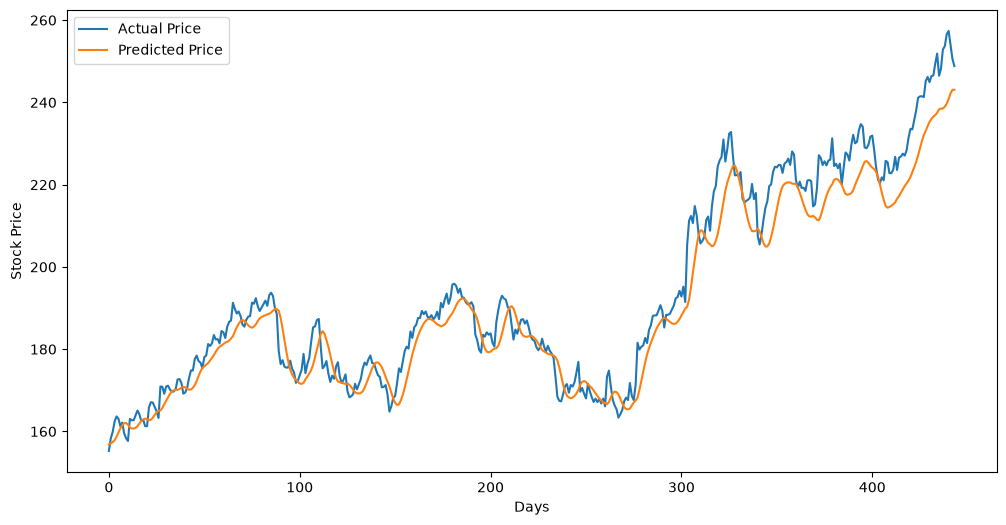

In [47]:
plt.figure(figsize=(12,6))

plt.plot(actual, label="Actual Price")

plt.plot(predictions, label="Predicted Price")

plt.xlabel("Days")
plt.ylabel("Stock Price")

plt.legend()

plt.show()

In [48]:
rmse = np.sqrt(
    mean_squared_error(
        actual,
        predictions
    )
)

print("RMSE =", rmse)

RMSE = 6.247180819745916


In [49]:
model.save("stock_model.keras")

In [50]:
df.to_csv("AAPL.csv", index=False)